In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [24]:
a = pd.read_csv("/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/ekg_20251230_160600.csv")

In [25]:
print(a.head())
print(a.columns)

   time_s  adc_raw  voltage
0  0.0000      426   1.3742
1  0.0141        0   0.0000
2  0.0184        0   0.0000
3  0.0228      912   2.9419
4  0.0271        0   0.0000
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


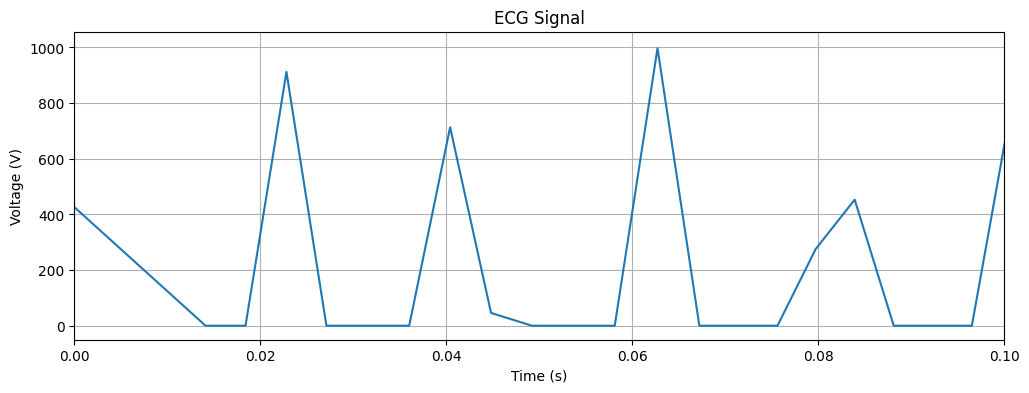

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(a['time_s'], a['adc_raw'])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.xlim(xmin=0, xmax=0.1)  # Adjust x-axis limits as needed
plt.title('ECG Signal')
plt.grid()
plt.show()

In [35]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.signal import find_peaks, butter, filtfilt

import os

DATA_ROOT = "/Users/alstanlin/Desktop/CAT-NET for Arrhythmia Detection/dataujicoba"

files = [f for f in os.listdir(DATA_ROOT) if f.endswith('.csv')]
print(files)

['ekg_20251230_160341.csv', 'ekg_20251230_162828.csv', 'ekg_20251230_172132.csv', 'ekg_20251230_154651.csv', 'ekg_20251230_162856.csv', 'ekg_20251230_172138.csv', 'ekg_20251230_163052.csv', 'ekg_20251230_172212.csv', 'ekg_20251230_163108.csv', 'ekg_20251230_160600.csv']


In [36]:
import pandas as pd

all_data = []

for file in files:
    path = os.path.join(DATA_ROOT, file)
    df = pd.read_csv(path)
    
    df['source_file'] = file  # optional (biar tahu asal data)
    all_data.append(df)

# Gabungkan semua
data = pd.concat(all_data, ignore_index=True)

print(data.head())

   time_s  adc_raw  voltage              source_file
0  0.0000        0      0.0  ekg_20251230_160341.csv
1  0.0044        0      0.0  ekg_20251230_160341.csv
2  0.0087        0      0.0  ekg_20251230_160341.csv
3  0.0130        0      0.0  ekg_20251230_160341.csv
4  0.0173        0      0.0  ekg_20251230_160341.csv



File: ekg_20251230_160341.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


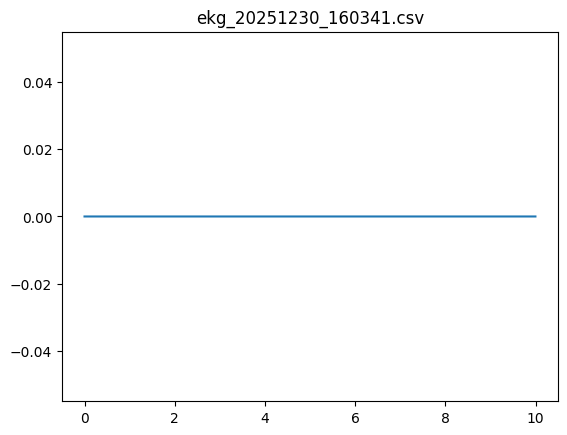


File: ekg_20251230_162828.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


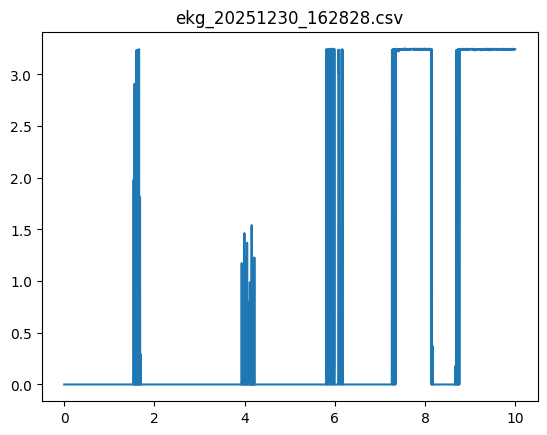


File: ekg_20251230_172132.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


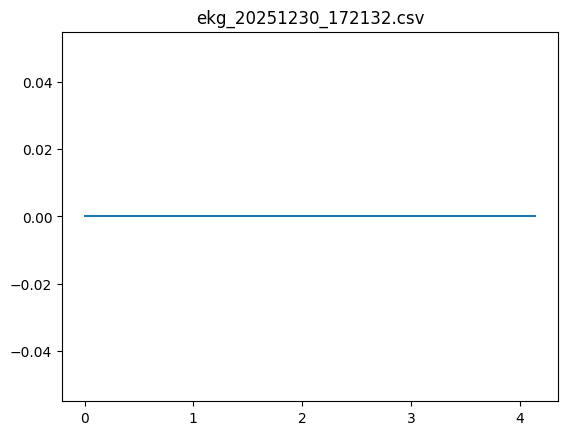


File: ekg_20251230_154651.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


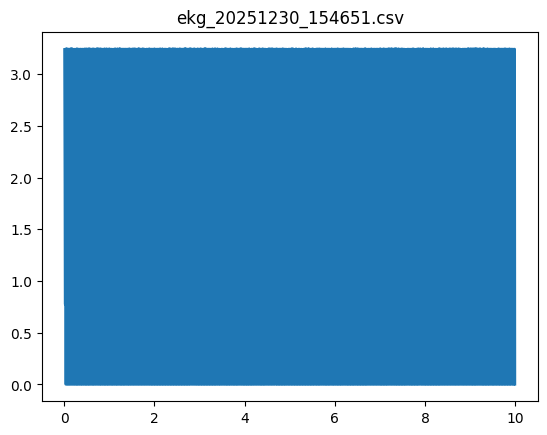


File: ekg_20251230_162856.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


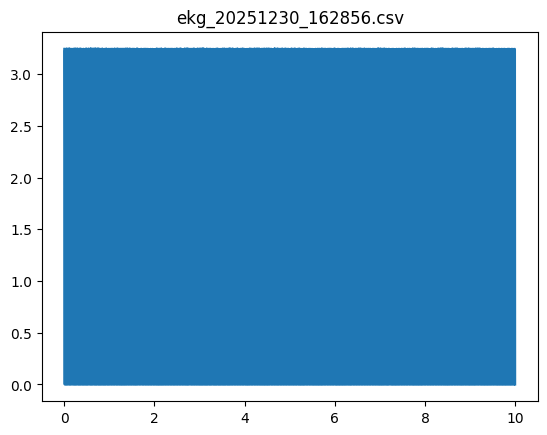


File: ekg_20251230_172138.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


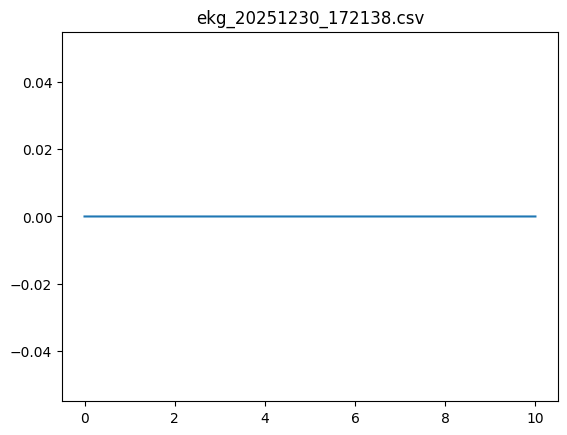


File: ekg_20251230_163052.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


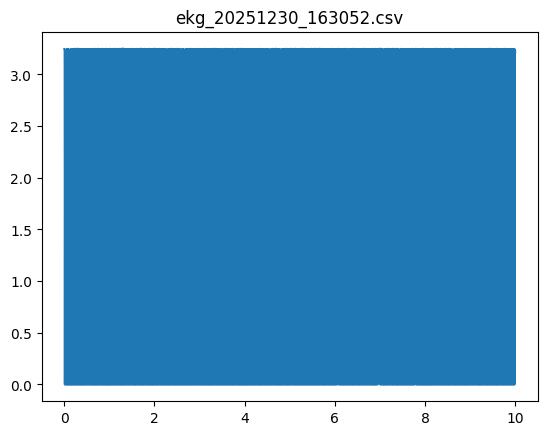


File: ekg_20251230_172212.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


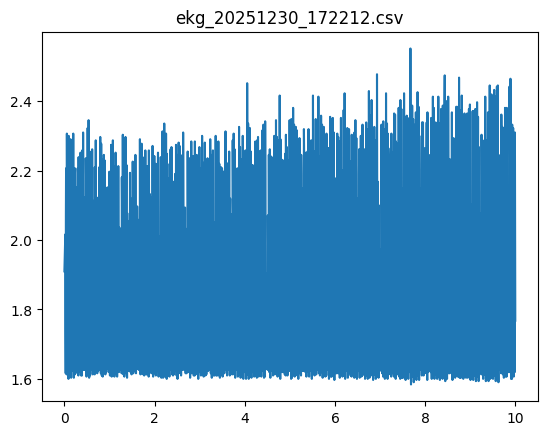


File: ekg_20251230_163108.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


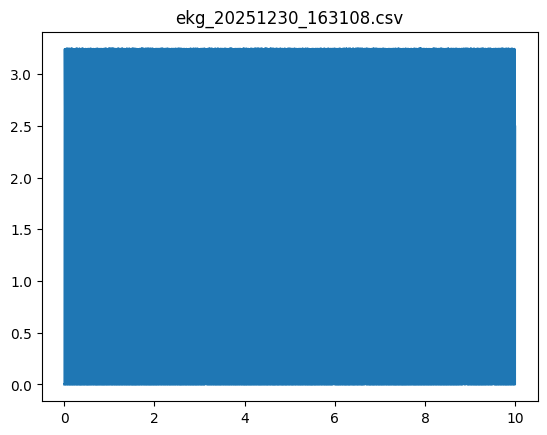


File: ekg_20251230_160600.csv
Index(['time_s', 'adc_raw', 'voltage'], dtype='object')


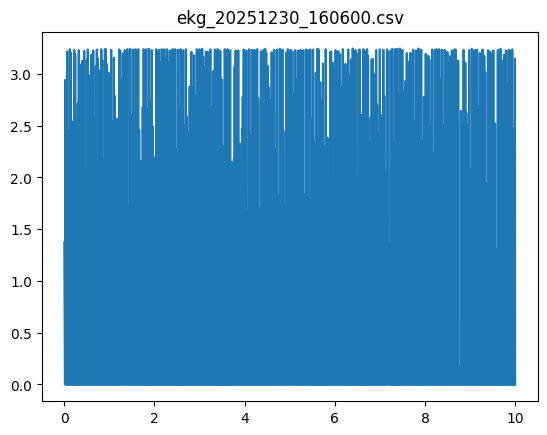

In [40]:
for file in files:
    path = os.path.join(DATA_ROOT, file)
    df = pd.read_csv(path)

    print(f"\nFile: {file}")
    print(df.columns)

    time_date = df['time_s'].values
    voltage_data = df['voltage'].values

    # contoh: plot
    import matplotlib.pyplot as plt
    plt.plot(time_date, voltage_data)
    plt.title(file)
    plt.show()

In [41]:
file = files[0]
path = os.path.join(DATA_ROOT, file)

df = pd.read_csv(path)

# cleaning
df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
df['voltage'] = pd.to_numeric(df['voltage'], errors='coerce')
df = df.dropna()

# numpy
time_date = df['time_s'].values
voltage_data = df['voltage'].values

# preprocessing
voltage_data = voltage_data - np.mean(voltage_data)

print("Jumlah Data:", len(time_date))
print("Min-Max:", np.min(voltage_data), np.max(voltage_data))

Jumlah Data: 2329
Min-Max: 0.0 0.0



=== Processing: ekg_20251230_160341.csv ===
❌ Skip (sinyal flat)

=== Processing: ekg_20251230_162828.csv ===
Jumlah Peak: 3
Rata-rata BPM: 65.4399557277255


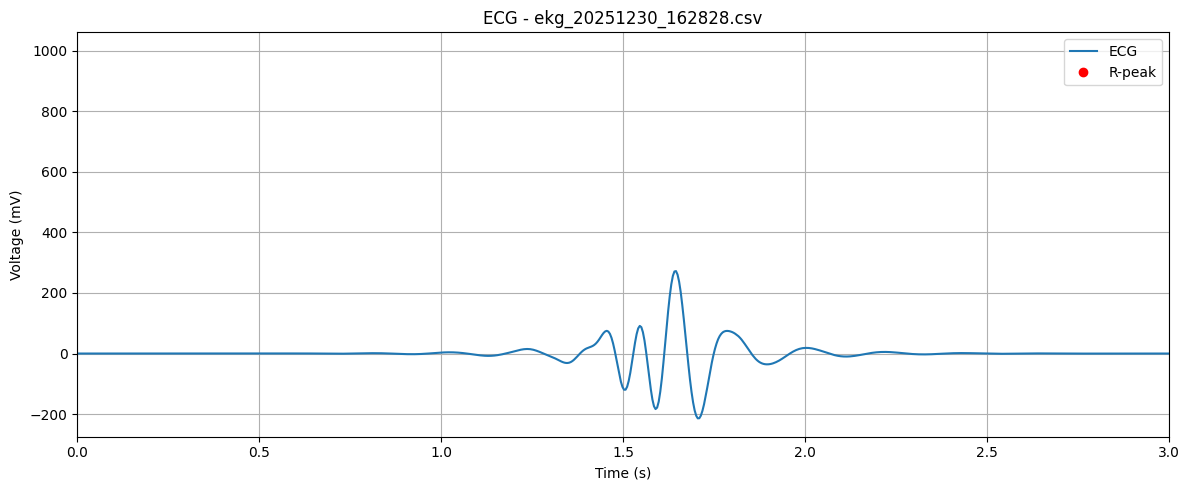


=== Processing: ekg_20251230_172132.csv ===
❌ Skip (sinyal flat)

=== Processing: ekg_20251230_154651.csv ===
Jumlah Peak: 1
⚠️ Peak terlalu sedikit


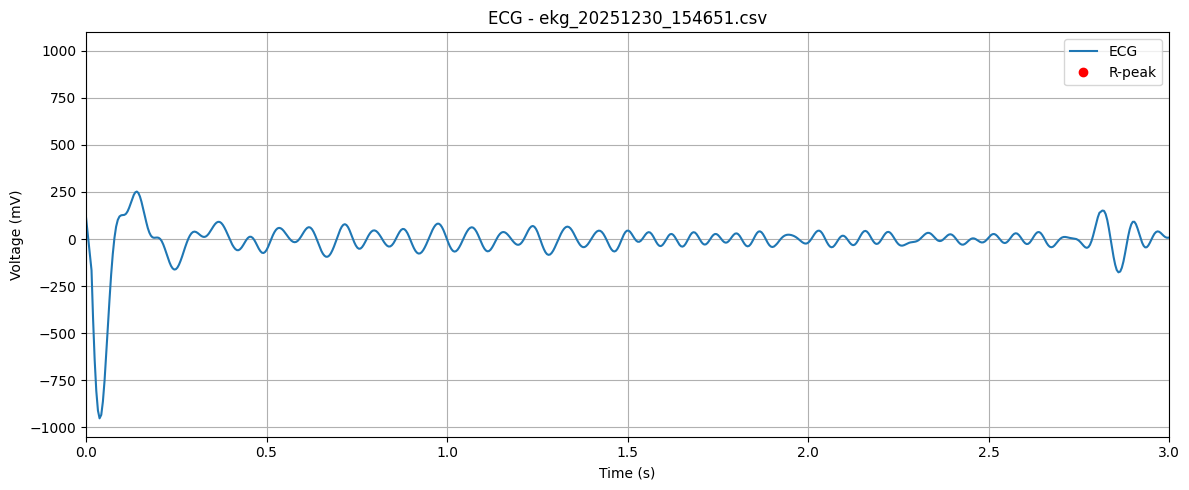


=== Processing: ekg_20251230_162856.csv ===
Jumlah Peak: 1
⚠️ Peak terlalu sedikit


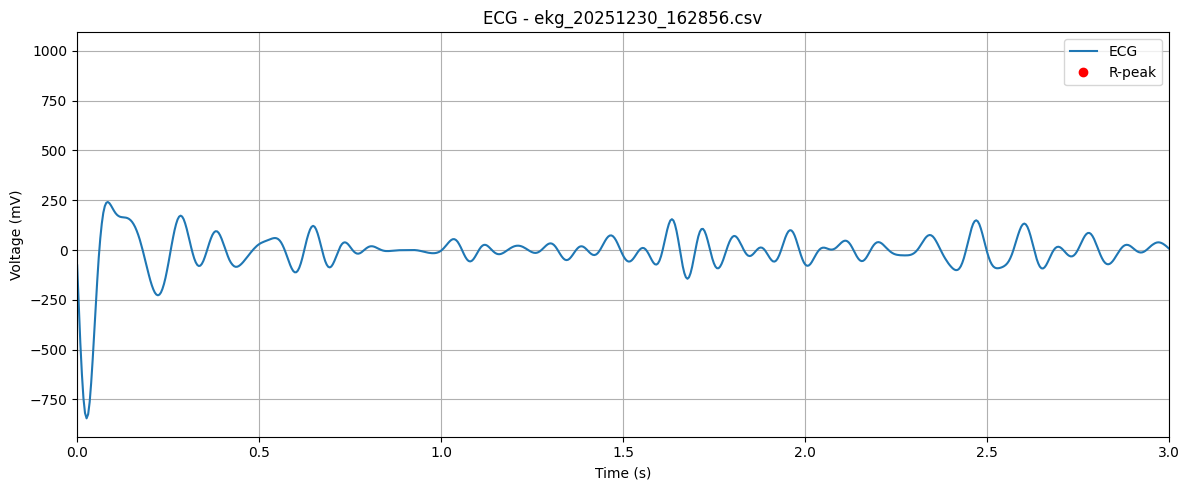


=== Processing: ekg_20251230_172138.csv ===
❌ Skip (sinyal flat)

=== Processing: ekg_20251230_163052.csv ===
Jumlah Peak: 0
⚠️ Peak terlalu sedikit


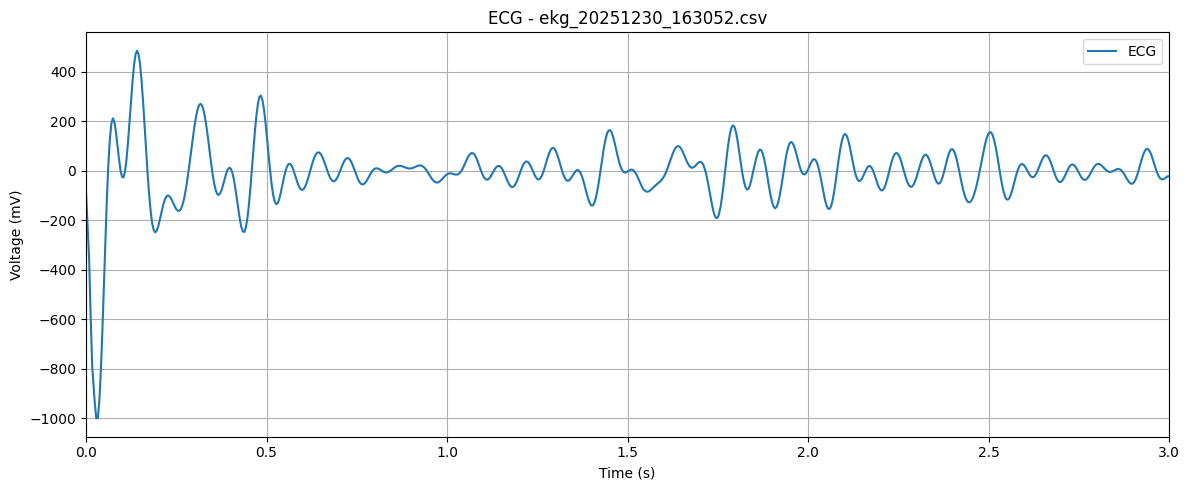


=== Processing: ekg_20251230_172212.csv ===
Jumlah Peak: 12
Rata-rata BPM: 103.75167065378895


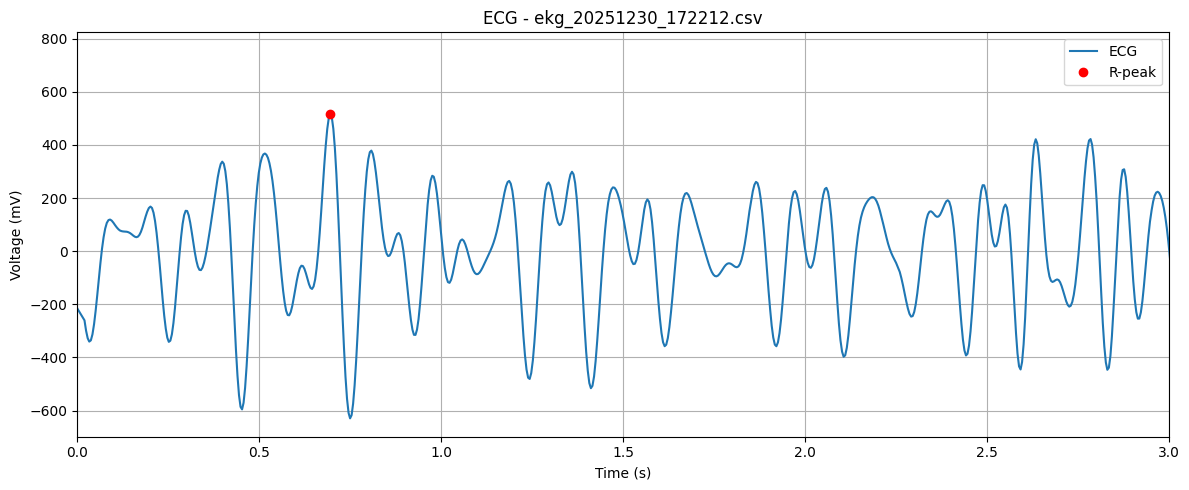


=== Processing: ekg_20251230_163108.csv ===
Jumlah Peak: 1
⚠️ Peak terlalu sedikit


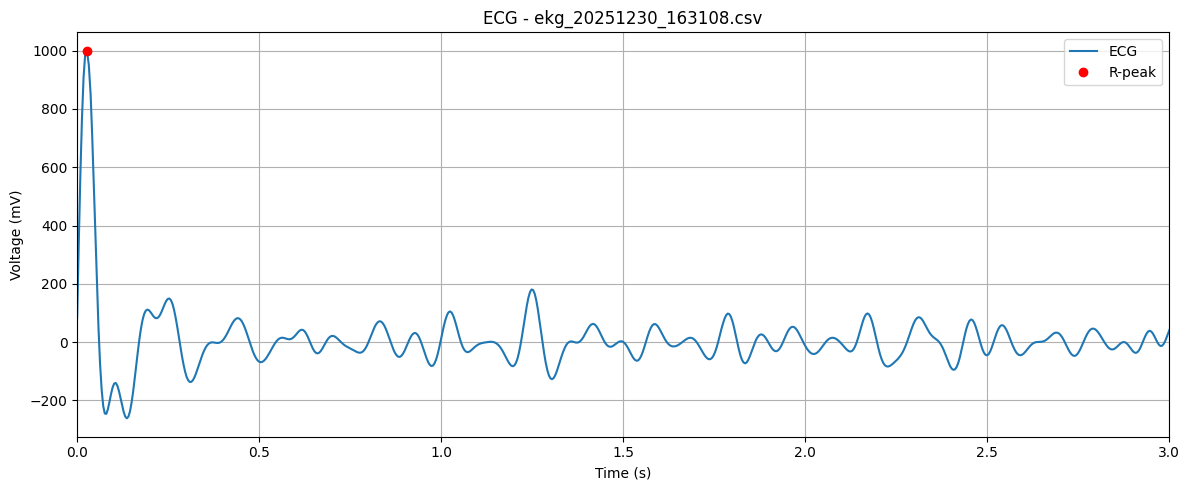


=== Processing: ekg_20251230_160600.csv ===
Jumlah Peak: 5
Rata-rata BPM: 53.31050233243677


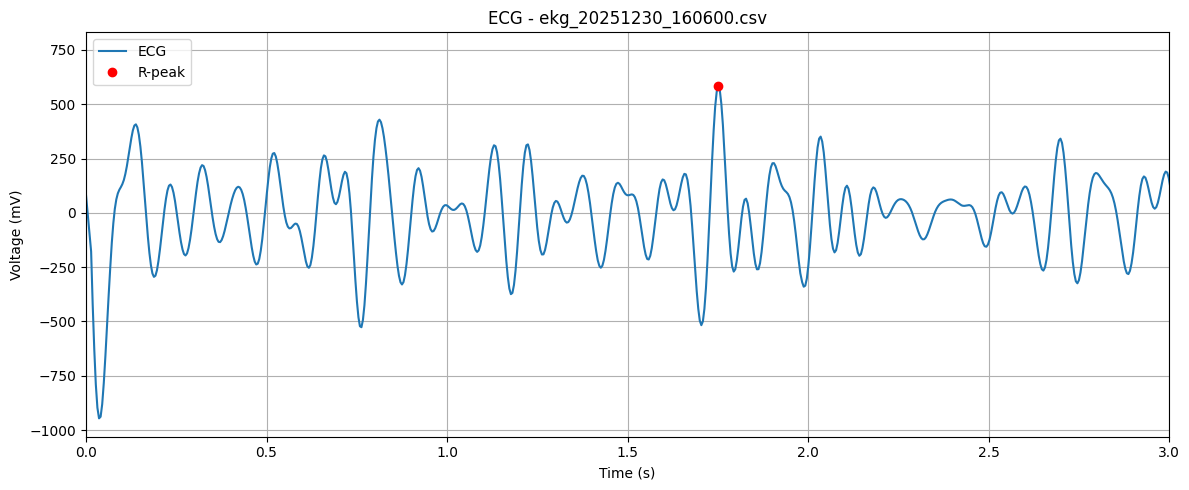

In [49]:
# === PARAMETER ===
fs = 250
lowcut = 5
highcut = 15

b, a = butter(4, [lowcut / (0.5 * fs), highcut / (0.5 * fs)], btype='band')

# === LOOP SEMUA FILE ===
for file in files:
    print(f"\n=== Processing: {file} ===")
    
    path = os.path.join(DATA_ROOT, file)
    df = pd.read_csv(path)

    # === CLEANING ===
    if not all(col in df.columns for col in ['time_s', 'voltage']):
        print("❌ Skip (kolom tidak sesuai)")
        continue

    df['time_s'] = pd.to_numeric(df['time_s'], errors='coerce')
    df['voltage'] = pd.to_numeric(df['voltage'], errors='coerce')
    df = df.dropna()

    if len(df) < 500:
        print("❌ Skip (data terlalu sedikit)")
        continue

    # === DATA ===
    time_date = df['time_s'].values
    voltage_data = df['voltage'].values

    # === PREPROCESSING ===
    voltage_data = voltage_data - np.mean(voltage_data)

    # === FILTER ===
    ekg_filtered = filtfilt(b, a, voltage_data)

    # === NORMALISASI ===
    if np.max(np.abs(ekg_filtered)) == 0:
        print("❌ Skip (sinyal flat)")
        continue

    ekg_norm = ekg_filtered / np.max(np.abs(ekg_filtered))

    # === PEAK DETECTION ===
    threshold = 0.5
    min_distance = int(0.4 * fs)

    peaks, _ = find_peaks(
        ekg_norm,
        height=threshold,
        distance=min_distance
    )

    print("Jumlah Peak:", len(peaks))

    # === BPM ===
    rr_intervals = np.diff(peaks) / fs

    if len(rr_intervals) > 0:
        bpm = 60 / rr_intervals
        print("Rata-rata BPM:", np.mean(bpm))
    else:
        print("⚠️ Peak terlalu sedikit")

    # === SCALING ===
    ekg_mV = ekg_norm * 1000

    # === PLOT ===
    duration = 3
    samples = int(duration * fs)

    plt.figure(figsize=(12, 5))
    plt.plot(time_date[:samples], ekg_mV[:samples], label='ECG')

    if len(peaks) > 0:
        plt.plot(time_date[peaks], ekg_mV[peaks], 'ro', label='R-peak')

    plt.title(f"ECG - {file}")
    plt.xlabel("Time (s)")
    plt.ylabel("Voltage (mV)")
    plt.xlim(time_date[0], time_date[0] + duration)
    plt.grid()
    plt.legend()
    plt.tight_layout()
    plt.show()